In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def py_dir(filename):
    return "./MST_O_logn_logn/" + filename 
    
def cpp_dir(filename):
    return "./MST_O_logn_logn_C-/" + filename 

def cuda_dir(filename):
    return "./MST_O_logn_logn_Cuda/" + filename 

## Strong scaling

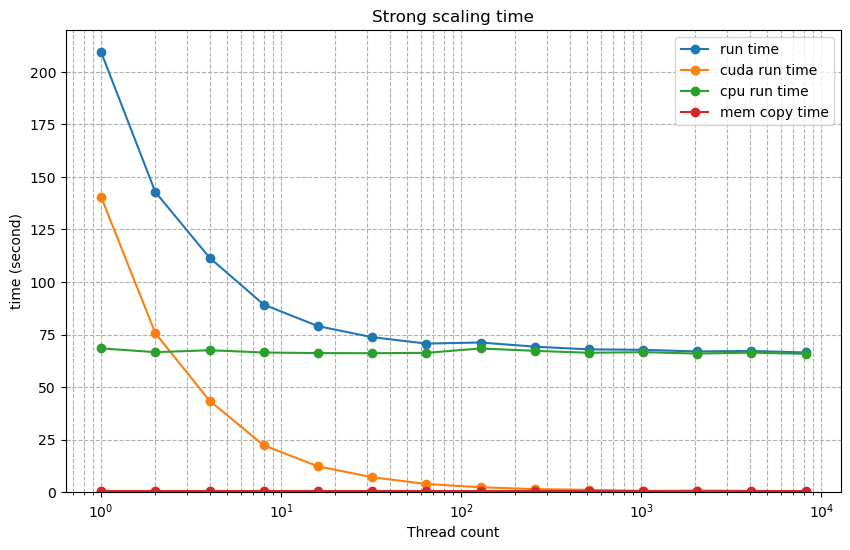

In [40]:
df = pd.read_csv(cuda_dir('strong_scale_original/strong_scale.csv'))

x = df["num_threads"]
# 8, 16, 32, ..., 128, 256

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_cuda'] / 1000, label='run time', marker='o')

cuda_time = df['t_kernel1'] + df['t_kernel2']
mcp_time = df['memcpy_dth'] + df['memcpy_htd']
cpu_time = df['t_cuda'] - cuda_time - mcp_time

plt.plot(x, cuda_time / 1000, label='cuda run time', marker='o')
plt.plot(x, cpu_time / 1000, label='cpu run time', marker='o')
plt.plot(x, mcp_time / 1000, label='mem copy time', marker='o')

plt.xlabel('Thread count')
plt.ylabel('time (second)')
plt.title('Strong scaling time')
plt.xscale('log')

plt.ylim(bottom=0)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

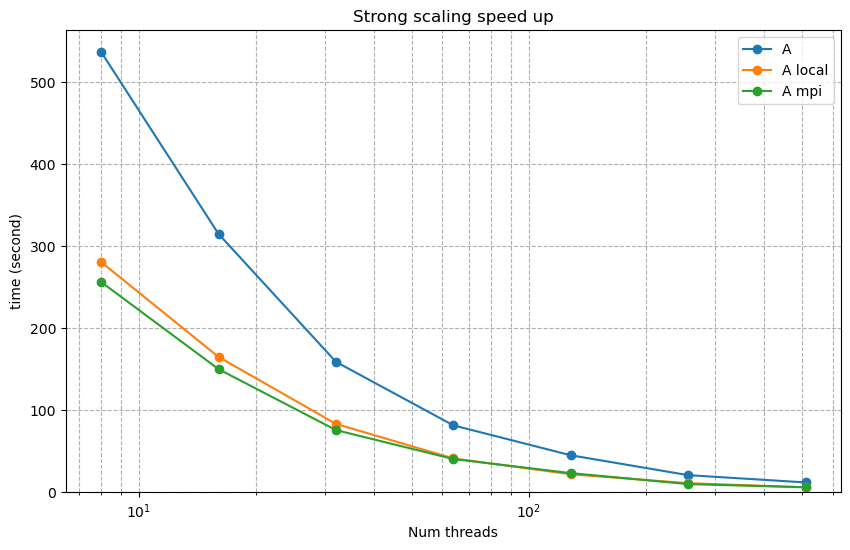

In [39]:
df = pd.read_csv(py_dir('strong_scaling/strong_scale.csv'))
x = df["num_proc"]
# 8, 16, 32, ..., 128, 256

ideal_speedup = [2**i for i in range(len(df['t_dist']))]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_dist'], label='A', marker='o')
plt.plot(x, df['t_dist_seq'], label='A local', marker='o')
plt.plot(x, df['t_dist_mpi'], label='A mpi', marker='o')

plt.xlabel('Num threads')
plt.ylabel('time (second)')
plt.title('Strong scaling speed up')
plt.ylim(bottom=0)
plt.xscale('log')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

The local run time for cuda does not change during strong scaling.
It changes with MPI because locally each node need to prepare data for mpi transmission. mor thread means less data to prepare locally.

In [7]:
def get_speed_up(t_arr):
    initial = t_arr[0]
    speedup = 1
    
    result = [speedup]
    
    for i in range(1, len(t_arr)):
        result.append((initial / t_arr[i]))
        
    return result

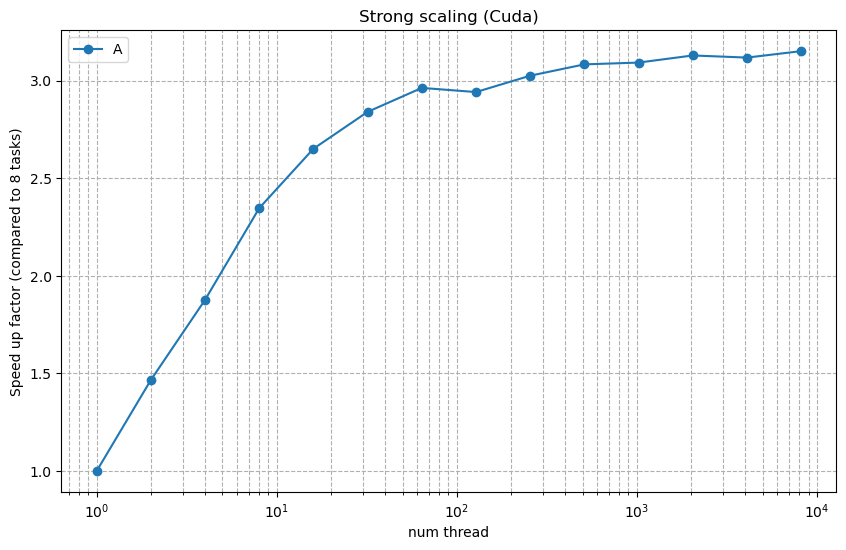

In [41]:
df = pd.read_csv(cuda_dir('strong_scale_original/strong_scale.csv'))

x = df["num_threads"]

x = list(df["num_threads"])[::-1]
# 8, 16, 32, ..., 128, 256

ideal_speedup = [2**i for i in range(len(df['num_threads']))]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, get_speed_up(list(df['t_cuda'])[::-1]), label='A', marker='o')

plt.xlabel('num thread')
plt.ylabel('Speed up factor (compared to 8 tasks)')
plt.title('Strong scaling (Cuda)')
plt.xscale('log')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

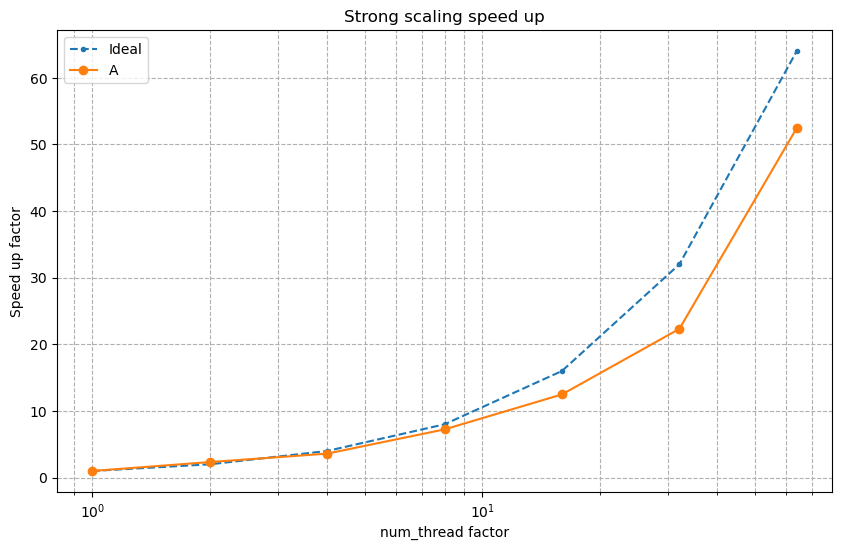

In [42]:
df = pd.read_csv(cpp_dir('strong_scaling/strong_scale.csv'))

x = df["num_proc"] / 8
# 8, 16, 32, ..., 128, 256

ideal_speedup = [2**i for i in range(len(df['t_mpi']))]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, ideal_speedup, label='Ideal', marker='.', linestyle="--")
plt.plot(x, get_speed_up(df['t_mpi']), label='A', marker='o')


plt.xlabel('num_thread factor')
plt.ylabel('Speed up factor')
plt.title('Strong scaling speed up')
plt.xscale('log')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Performance